<a href="https://colab.research.google.com/github/anyakdard/ocean-acoustics/blob/main/04_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# new machine learning libraries
import tensorflow as tf
# tensorflow Google's open source machine learning framework
# most widely used library for building neural networks

from tensorflow import keras
# keras high level API built on top of tensorflow
# makes building neural networks readable n concise

print('TensorFlow version:', tf.__version__)
print('Ready!')

TensorFlow version: 2.20.0
Ready!


In [ ]:
from PIL import Image
# Reinstall awscli
!pip install awscli -q
# -q means quiet - suppresses the installation output so it's less cluttered

# Re-download the data
!aws s3 cp s3://acoustic-sandbox/labeled-data/detection/train/TestDataLatest_PodCastAllRounds_123.tar.gz /content/orcadata.tar.gz --no-sign-request

# Extract it
!mkdir -p /content/orcadata
!tar -xzf /content/orcadata.tar.gz -C /content/orcadata

print('Data ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://acoustic-sandbox/labeled-data/detection/train/TestDataLatest_PodCastAllRounds_123.tar.gz to ./orcadata.tar.gz
Data ready!


In [ ]:
model = tf.keras.models.load_model('/content/transfer_model.keras')
print('Model loaded!')
print('Input shape:', model.input_shape)

Model loaded!
Input shape: (None, 128, 128, 3)


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'orcadata', 'orcadata.tar.gz', 'sample_data']


In [ ]:
def detect_orca_calls(audio_path, model, threshold=0.1,
                      window_duration=1.5, step_size=0.5):
    """
    Scan an audio file for orca calls and return detected timestamps.

    audio_path      - path to the wav file to scan
    model           - trained classifier
    threshold       - probability above which I'm calling it an orca (0.1 from analysis)
    window_duration - length of each chunk in seconds (1.5 matches training data)
    step_size       - how far to move the window each step in seconds
                      0.5 means windows overlap by 1.0 second
                      smaller step = more overlap = less likely to miss calls
                      but slower to run
    """

    print(f'Loading audio: {audio_path}')
    y, sr = librosa.load(audio_path, sr=22050)
    # sr=22050 explicitly sets the sample rate
    # this ensures consistency regardless of the original file's sample rate
    # all training data was loaded at 22050 so we must match it

    total_duration = librosa.get_duration(y=y, sr=sr)
    print(f'Total duration: {total_duration:.1f} seconds')

    # Calculate how many windows to process
    n_windows = int((total_duration - window_duration) / step_size)
    print(f'Windows to process: {n_windows}')

    detections = []
    # detections will store timestamps where we find orca calls

    print('Scanning...')
    for i in range(n_windows):
        # Calculate start and end time for this window
        start_time = i * step_size
        end_time = start_time + window_duration
        # i=0: 0.0s to 1.5s
        # i=1: 0.5s to 2.0s
        # i=2: 1.0s to 2.5s etc.

        # Extract the audio chunk for this window
        start_sample = int(start_time * sr)
        end_sample = int(end_time * sr)
        # samples are the individual measurements in the audio array
        # multiplying time by sample rate converts seconds to sample indices
        # e.g. 2.5 seconds * 22050 samples/second = sample 55125
        chunk = y[start_sample:end_sample]
        # slicing the array with [start:end]
                # Generate mel spectrogram for this chunk
        M = librosa.feature.melspectrogram(y=chunk, sr=sr)
        M_db = librosa.amplitude_to_db(M, ref=np.max)

        # Convert spectrogram to an image array the model can read
        # we need to match exactly what we did during training:
        # 128x128 pixels, 3 colour channels, normalised to 0-1
        fig, ax = plt.subplots(figsize=(2, 2))
        librosa.display.specshow(M_db, sr=sr, ax=ax)
        ax.axis('off')

        # Instead of saving to disk, render to a numpy array in memory
        fig.canvas.draw()
        # canvas.draw() renders the figure without displaying it
        buf = fig.canvas.buffer_rgba()
        # buffer_rgba() grabs the raw pixel data from the rendered figure
        # rgba = red, green, blue, alpha (transparency)
        img_array = np.asarray(buf)
        # convert buffer to numpy array
        plt.close(fig)

        # Resize to 128x128 and drop the alpha channel, keep RGB
        img = Image.fromarray(img_array)
        # Image.fromarray() converts numpy array to a PIL image object
        img = img.resize((128, 128))
        # resize to match our training image size
        img_array = np.array(img)[:, :, :3]
        # [:, :, :3] keeps all rows, all columns, but only first 3 channels
        # dropping the 4th alpha channel since our model expects 3 channels
        img_array = img_array / 255.0
        # normalise to 0-1 as during training

        # Add batch dimension and run through model
        img_batch = np.expand_dims(img_array, axis=0)
        # expand_dims adds an extra dimension at position 0
        # model expects shape (batch_size, 128, 128, 3)
        # our single image is (128, 128, 3)
        # expand_dims makes it (1, 128, 128, 3) - a batch of one

        probability = model.predict(img_batch, verbose=0)[0][0]
        # verbose=0 suppresses the progress bar for each prediction
        # [0][0] extracts the single probability value from the output

        if probability > threshold:
            detections.append({
                'start_time': start_time,
                'end_time': end_time,
                'probability': probability
            })
            # store as a dictionary with all relevant info
            # a dictionary stores key-value pairs like a lookup table
            # e.g. detections[0]['start_time'] gives the start time
            # of the first detection

    print(f'Scan complete! Found {len(detections)} detections')
    return detections

In [ ]:
import librosa
import librosa.display
# Test on a short file first
test_wav = '/content/orcadata/wav/OS_7_05_2019_08_24_00_.wav'

detections = detect_orca_calls(test_wav, model, threshold=0.1)

print(f'\nFirst 10 detections:')
for d in detections[:10]:
    print(f"  {d['start_time']:.1f}s - {d['end_time']:.1f}s  "
          f"(probability: {d['probability']:.3f})")


Loading audio: /content/orcadata/wav/OS_7_05_2019_08_24_00_.wav
Total duration: 1800.2 seconds
Windows to process: 3597
Scanning...
Scan complete! Found 3529 detections

First 10 detections:
  0.0s - 1.5s  (probability: 0.514)
  0.5s - 2.0s  (probability: 0.255)
  1.0s - 2.5s  (probability: 0.825)
  1.5s - 3.0s  (probability: 0.971)
  2.0s - 3.5s  (probability: 0.988)
  2.5s - 4.0s  (probability: 0.815)
  3.0s - 4.5s  (probability: 0.739)
  3.5s - 5.0s  (probability: 0.865)
  4.0s - 5.5s  (probability: 0.554)
  4.5s - 6.0s  (probability: 0.970)


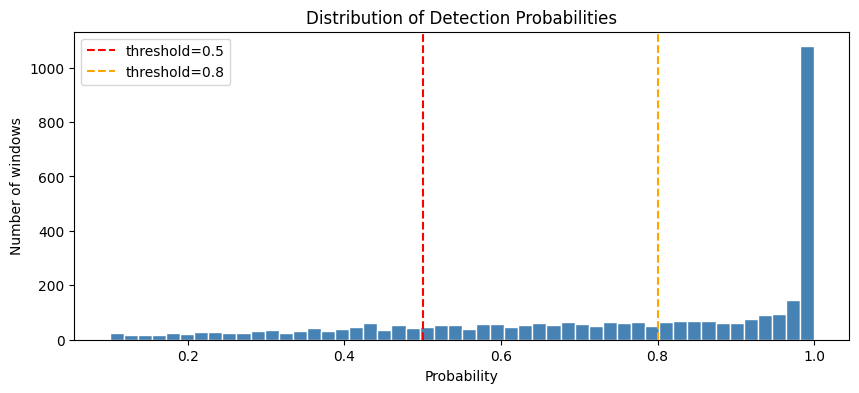

Threshold 0.3: 92.4% of windows flagged
Threshold 0.5: 79.7% of windows flagged
Threshold 0.7: 62.8% of windows flagged
Threshold 0.8: 53.3% of windows flagged
Threshold 0.9: 43.1% of windows flagged


In [ ]:
# that's way too many, should be like 1000 ish
# could be a bad threshold
# I tested threshold 01 on individual, pre-cropped spectrogram images
# this is different cos I'm rendering via matplotlib rather than saving and
# reloading PNG files
# visual output is different which shifts the probability distribution

## also could be cos I need post-processing (even w a good threshold)
# overlapping windows so a single call can be detected multiple times
# so need to merge overlapping detections into single events

# below histogram will tell me where natural separation between orca calls and natural noise sits

# Look at the distribution of probabilities to find a natural cutoff
probabilities = []

# Rerun but just collect probabilities, don't filter yet
for d in detections:
    probabilities.append(d['probability'])

probabilities = np.array(probabilities)

# Plot a histogram of all probabilities
# a histogram shows how many values fall into each range
plt.figure(figsize=(10, 4))
plt.hist(probabilities, bins=50, color='steelblue', edgecolor='white')
# bins=50 divides the 0-1 range into 50 buckets
# edgecolor adds white lines between bars for readability
plt.xlabel('Probability')
plt.ylabel('Number of windows')
plt.title('Distribution of Detection Probabilities')
plt.axvline(x=0.5, color='red', linestyle='--', label='threshold=0.5')
plt.axvline(x=0.8, color='orange', linestyle='--', label='threshold=0.8')
# axvline draws a vertical line at a specific x position
plt.legend()
plt.show()

# Print what percentage of windows fall above different thresholds
for t in [0.3, 0.5, 0.7, 0.8, 0.9]:
    pct = (probabilities > t).mean() * 100
    print(f'Threshold {t}: {pct:.1f}% of windows flagged')

In [ ]:
# so this thinks every sound is an orca call
# fixing it by making it the same as I did when training

# going back to training notebook 02 and changing to retrain on numpy based spectrogram generation instead

